In [16]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse

# -------------------------------------------------------
# Global Plot Settings
# -------------------------------------------------------
# Set font to Arial
plt.rcParams['font.family'] = ['Arial', 'SimSun']
# plt.rcParams['font.sans-serif'] = ['Arial']

# Increase default font sizes
plt.rcParams['font.size'] = 16          # Base font size
# plt.rcParams['axes.labelsize'] = 16     # Axis label size
# plt.rcParams['xtick.labelsize'] = 14    # X-tick label size
# plt.rcParams['ytick.labelsize'] = 14    # Y-tick label size
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.unicode_minus'] = False

# 1. Load Data
# Ensure the file is in the working directory
df_curve = pd.read_csv('samples_for_correlation.csv')


In [17]:
print(df_curve['control_type'].groupby(df_curve['control_type']).count())
print(df_curve['label'].groupby(df_curve['label']).count())
# print(df)

control_type
1    2589
2     482
3      44
4     707
Name: control_type, dtype: int64
label
0    3143
1     679
Name: label, dtype: int64


In [18]:
# -------------------------------------------------------
# Step 1: Variable Filtering and "Natural Sorting"
# -------------------------------------------------------
# Extract columns starting with 'bio_'
bio_cols = [col for col in df_curve.columns if col not in ['label', 'system:index', '.geo'] ]

def natural_key(string_):
    """
    Splits string into text and number chunks for natural sorting.
    Example: sorts [bio_1, bio_2, bio_10] correctly instead of [bio_1, bio_10, bio_2].
    """
    return [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', string_)]

# Sort the column names
bio_cols_sorted = sorted(bio_cols, key=natural_key)

# Subset the dataframe with sorted columns
data = df_curve[bio_cols_sorted]

# -------------------------------------------------------
# Step 2: Calculate Spearman Correlation Matrix
# -------------------------------------------------------
# Using Spearman as per your previous context (non-parametric)
corr = data.corr(method='spearman')

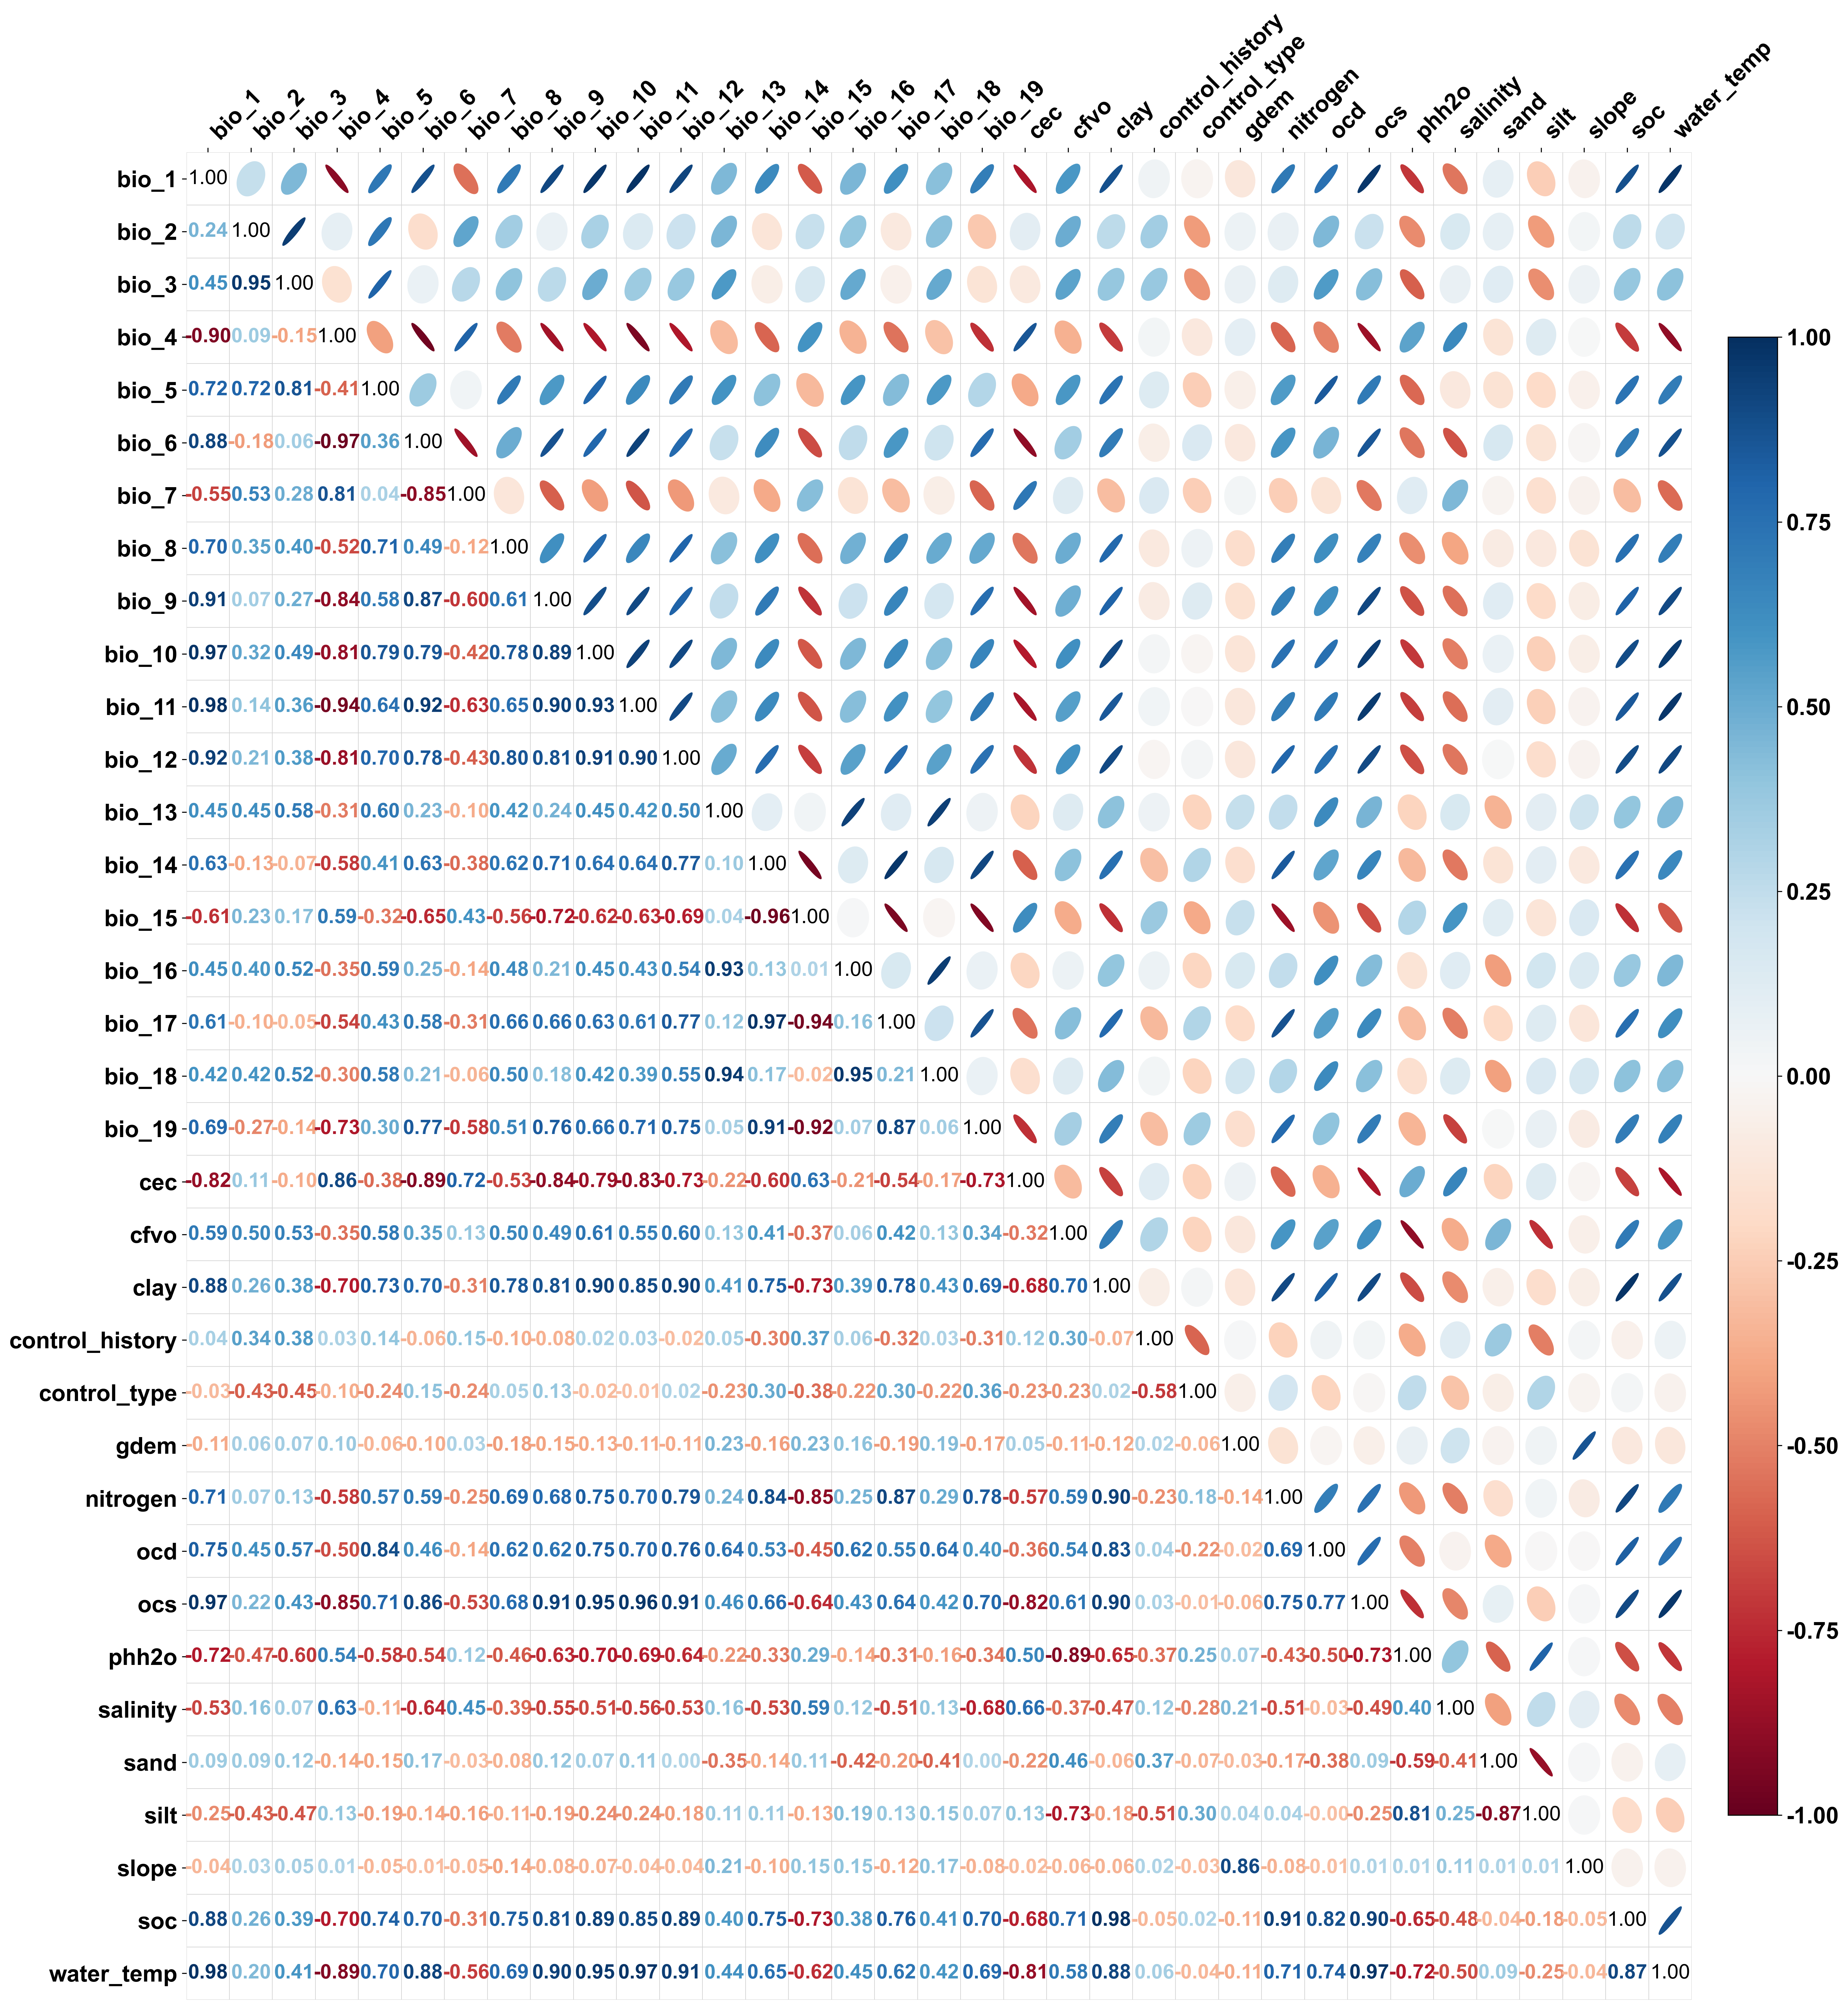

In [19]:
# -------------------------------------------------------
# Step 3: Custom Plotting
# -------------------------------------------------------

def draw_ellipse(ax, x, y, corr_value, cmap, norm):
    """
    Draws an ellipse at (x, y) representing the correlation value.
    - Shape: Flattened based on correlation strength (abs(corr)).
    - Color: Mapped from the colormap (Blue=Positive, Red=Negative).
    - Orientation: 45 degrees for positive, 135 for negative.
    """
    # Map correlation value to color
    color = cmap(norm(corr_value))
    
    # Scale factor to prevent ellipses from touching grid lines
    scale = 0.75
    
    # Calculate raw "flatness" (1.0 = circle, 0.0 = line)
    raw_flatness = 1 - abs(corr_value)
    
    # Set a minimum thickness threshold (0.2). 
    # Even if correlation is 0.99, the ellipse won't be thinner than 0.2.
    min_thickness = 0.2
    
    if raw_flatness < min_thickness:
        width_factor = min_thickness
    else:
        width_factor = raw_flatness

    minor = width_factor * scale
    major = 1.0 * scale
    
    # Angle: Positive -> 45°, Negative -> 135°
    angle = 45 if corr_value > 0 else 135
    
    # Add Ellipse patch to the axis
    ell = Ellipse(xy=(x, y), width=minor, height=major, angle=angle, 
                  edgecolor='none', facecolor=color)
    ax.add_patch(ell)

# Initialize Figure and Axes
# Figure size increased to accommodate larger fonts
fig, ax = plt.subplots(figsize=(22, 22), dpi=300)

# Define Colormap (Red-White-Blue)
cmap = plt.get_cmap('RdBu')
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Get matrix dimensions
n = len(corr)

# Loop through rows and columns to draw elements
for i in range(n):
    for j in range(n):
        val = corr.iloc[i, j]
        
# --- Lower Triangle (i > j): Draw Values ---
        if i > j: 
            # 重新计算一个用于文字的颜色映射值，避开 0.4 - 0.6 的白色区域
            if val < 0:
                # 将 -1 到 0 映射到色盘的 0.0 到 0.35 (深红到中红)
                text_t = (val + 1) * 0.35
            else:
                # 将 0 到 1 映射到色盘的 0.65 到 1.0 (中蓝到深蓝)
                text_t = 0.65 + (val * 0.35)
            
            text_color = cmap(text_t)
            
            ax.text(j, i, f"{val:.2f}", 
                    ha='center', va='center', 
                    color=text_color, 
                    fontweight='bold')
            
        # --- Upper Triangle (i < j): Draw Ellipses ---
        elif i < j:
            # Add a light background grid for ellipses
            # rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor='#fafafa', edgecolor='white')
            # ax.add_patch(rect)
            
            draw_ellipse(ax, j, i, val, cmap, norm)
            
        # --- Diagonal (i == j): Draw 1.00 ---
        else:
            ax.text(j, i, "1.00", 
                    ha='center', va='center', 
                    color='black', 
                    fontweight='normal')

# -------------------------------------------------------
# Formatting the Plot
# -------------------------------------------------------

# Set axis limits
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5) # Invert Y-axis so first variable is at top

# Set ticks
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

# Set labels with natural sorted names
ax.set_xticklabels(bio_cols_sorted, rotation=45, ha='left')
ax.set_yticklabels(bio_cols_sorted)

# Move X-axis labels to the top
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=18)

# Remove the outer box spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Add Grid lines (optional, helps separate cells)
ax.set_xticks(np.arange(n+1)-0.5, minor=True)
ax.set_yticks(np.arange(n+1)-0.5, minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02, aspect=30)
# cbar.set_label('Spearman Correlation', rotation=270, labelpad=25)
cbar.ax.tick_params(labelsize=18)

# No title as requested
# plt.title("...", ...) 

plt.tight_layout()
plt.show()

In [20]:
df_contrib_raw = pd.read_csv('maxent_contribution.csv')
clean_contrib = df_contrib_raw.drop(columns=[c for c in ['system:index', '.geo', '__unused__'] if c in df_contrib_raw.columns])
contrib_dict = clean_contrib.iloc[0].to_dict()
candidate_vars = [col for col in df_curve.columns if col in contrib_dict]

drop_set, threshold = set(), 0.80
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        
        if abs(val) > threshold:
            score_a = contrib_dict.get(row, 0)
            score_b = contrib_dict.get(col, 0)
            
            if score_a >= score_b:
                loser = col
                winner = row
                loser_score = score_b
                winner_score = score_a
            else:
                loser = row
                winner = col
                loser_score = score_a
                winner_score = score_b
            
            if loser not in drop_set:
                print(f"{row:<15} | {col:<15} | {val:.3f}    | {score_a:<8.2f} | {score_b:<8.2f} | 保留 {winner}, 剔除 {loser}")
                drop_set.add(loser)
                
final_selected_vars = [v for v in candidate_vars if v not in drop_set]
print("\n" + "="*40)
print("最终变量筛选结果")
print("="*40)
print(f"初始变量数量: {len(candidate_vars)}")
print(f"剔除变量数量: {len(drop_set)}")
print(f"保留变量数量: {len(final_selected_vars)}")

print("\n[建议剔除的变量]:")
print(list(drop_set))

print("\n[最终保留的变量] (可直接复制到 GEE 代码中):")
print(final_selected_vars)

bio_2           | bio_3           | 0.946    | 0.88     | 2.54     | 保留 bio_3, 剔除 bio_2
bio_1           | bio_4           | -0.902    | 0.01     | 0.66     | 保留 bio_4, 剔除 bio_1
bio_3           | bio_5           | 0.805    | 2.54     | 36.38    | 保留 bio_5, 剔除 bio_3
bio_4           | bio_6           | -0.975    | 0.66     | 0.13     | 保留 bio_4, 剔除 bio_6
bio_4           | bio_7           | 0.809    | 0.66     | 0.00     | 保留 bio_4, 剔除 bio_7
bio_4           | bio_9           | -0.842    | 0.66     | 0.08     | 保留 bio_4, 剔除 bio_9
bio_4           | bio_10          | -0.812    | 0.66     | 0.85     | 保留 bio_10, 剔除 bio_4
bio_1           | bio_11          | 0.984    | 0.01     | 0.00     | 保留 bio_1, 剔除 bio_11
bio_10          | bio_12          | 0.906    | 0.85     | 3.11     | 保留 bio_12, 剔除 bio_10
bio_14          | bio_15          | -0.957    | 0.15     | 3.22     | 保留 bio_15, 剔除 bio_14
bio_13          | bio_16          | 0.931    | 0.29     | 0.44     | 保留 bio_16, 剔除 bio_13
bio_15          | b

In [21]:
# Which rm & fc is best.
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

df_rmfc, results = pd.read_csv('MaxEnt_48_Predictions_TestSet.csv'), list()
grouped = df_rmfc.groupby(['config_id'])
for config_name, group in grouped:
    try:
        if isinstance(config_name, tuple):
            config_name = config_name[0]
        y_true = group['label']
        y_score = group['probability']
        
        # calc AUC
        auc = roc_auc_score(y_true, y_score)
        
        parts = config_name.split('_')
        rm_val = parts[0].replace('RM', '')
        fc_val = parts[1]
        
        results.append({
            'config_id': config_name,
            'RM': rm_val,
            'FC': fc_val,
            'Test_AUC': auc
        })
    except Exception as e:
        print(f"Error {config_name} : {e}")

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Test_AUC', ascending=False).reset_index(drop=True)

print("="*40)
print("🏆 Best FC & RM (Top 5)")
print("="*40)
print(df_results.head(5))

best_config = df_results.iloc[0]['config_id']
print(f'\nBest FC & RM —— |RM: {best_config.split('_')[0][2:]}, FC: {best_config.split('_')[1]}')


🏆 Best FC & RM (Top 5)
     config_id   RM     FC  Test_AUC
0  RM0.5_LQHPT  0.5  LQHPT  0.775896
1    RM1_LQHPT    1  LQHPT  0.772322
2  RM1.5_LQHPT  1.5  LQHPT  0.761843
3    RM2_LQHPT    2  LQHPT  0.756783
4    RM0.5_LQH  0.5    LQH  0.755999

Best FC & RM —— |RM: 0.5, FC: LQHPT


In [22]:
# MaxEnt 10 runs Test AUC, TSS, and AUC ratio.
final_maxent_aucs_10runs = pd.read_csv('MaxEnt_10Runs_auc.csv')
results = list()
run_ids = final_maxent_aucs_10runs['run_id'].unique()
run_ids.sort()

for run in run_ids:
    current_data = final_maxent_aucs_10runs[final_maxent_aucs_10runs['run_id'] == run]
    
    train_data = current_data[current_data['split'] == 'train']
    test_data = current_data[current_data['split'] == 'test']
    
    train_auc = roc_auc_score(train_data['label'], train_data['probability'])
    test_auc = roc_auc_score(test_data['label'], test_data['probability'])
    
    # AUC Ratio
    auc_ratio = test_auc / train_auc
    fpr, tpr, thresholds = roc_curve(train_data['label'], train_data['probability'])
    
    best_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[best_idx]
    
    test_preds = (test_data['probability'] >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_data['label'], test_preds).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    tss = sensitivity + specificity - 1
    results.append({
        'Run': int(run),
        'Test AUC': test_auc,
        'TSS': tss,
        'AUC ratios': auc_ratio,
        'Train AUC': train_auc, # 顺便存一下
        'Best Threshold': best_threshold
    })

df_metrics = pd.DataFrame(results)

# 计算平均值和标准差
print("=== 10次运行结果详情 ===")
print(df_metrics[['Run', 'Test AUC', 'TSS', 'AUC ratios']].round(4))

print("\n=== 统计摘要 (Mean ± Std) ===")
print(df_metrics[['Test AUC', 'TSS', 'AUC ratios']].agg(['mean', 'std']).round(4))

=== 10次运行结果详情 ===
   Run  Test AUC     TSS  AUC ratios
0    1    0.8079  0.4916      0.9473
1    2    0.7800  0.4347      0.9424
2    3    0.8077  0.4801      0.9599
3    4    0.7921  0.5062      0.9290
4    5    0.8239  0.4952      0.9827
5    6    0.7847  0.4667      0.9367
6    7    0.7867  0.4532      0.9477
7    8    0.8302  0.5104      0.9838
8    9    0.8079  0.4909      0.9503
9   10    0.7853  0.4521      0.9535

=== 统计摘要 (Mean ± Std) ===
      Test AUC     TSS  AUC ratios
mean    0.8007  0.4781      0.9533
std     0.0175  0.0253      0.0180


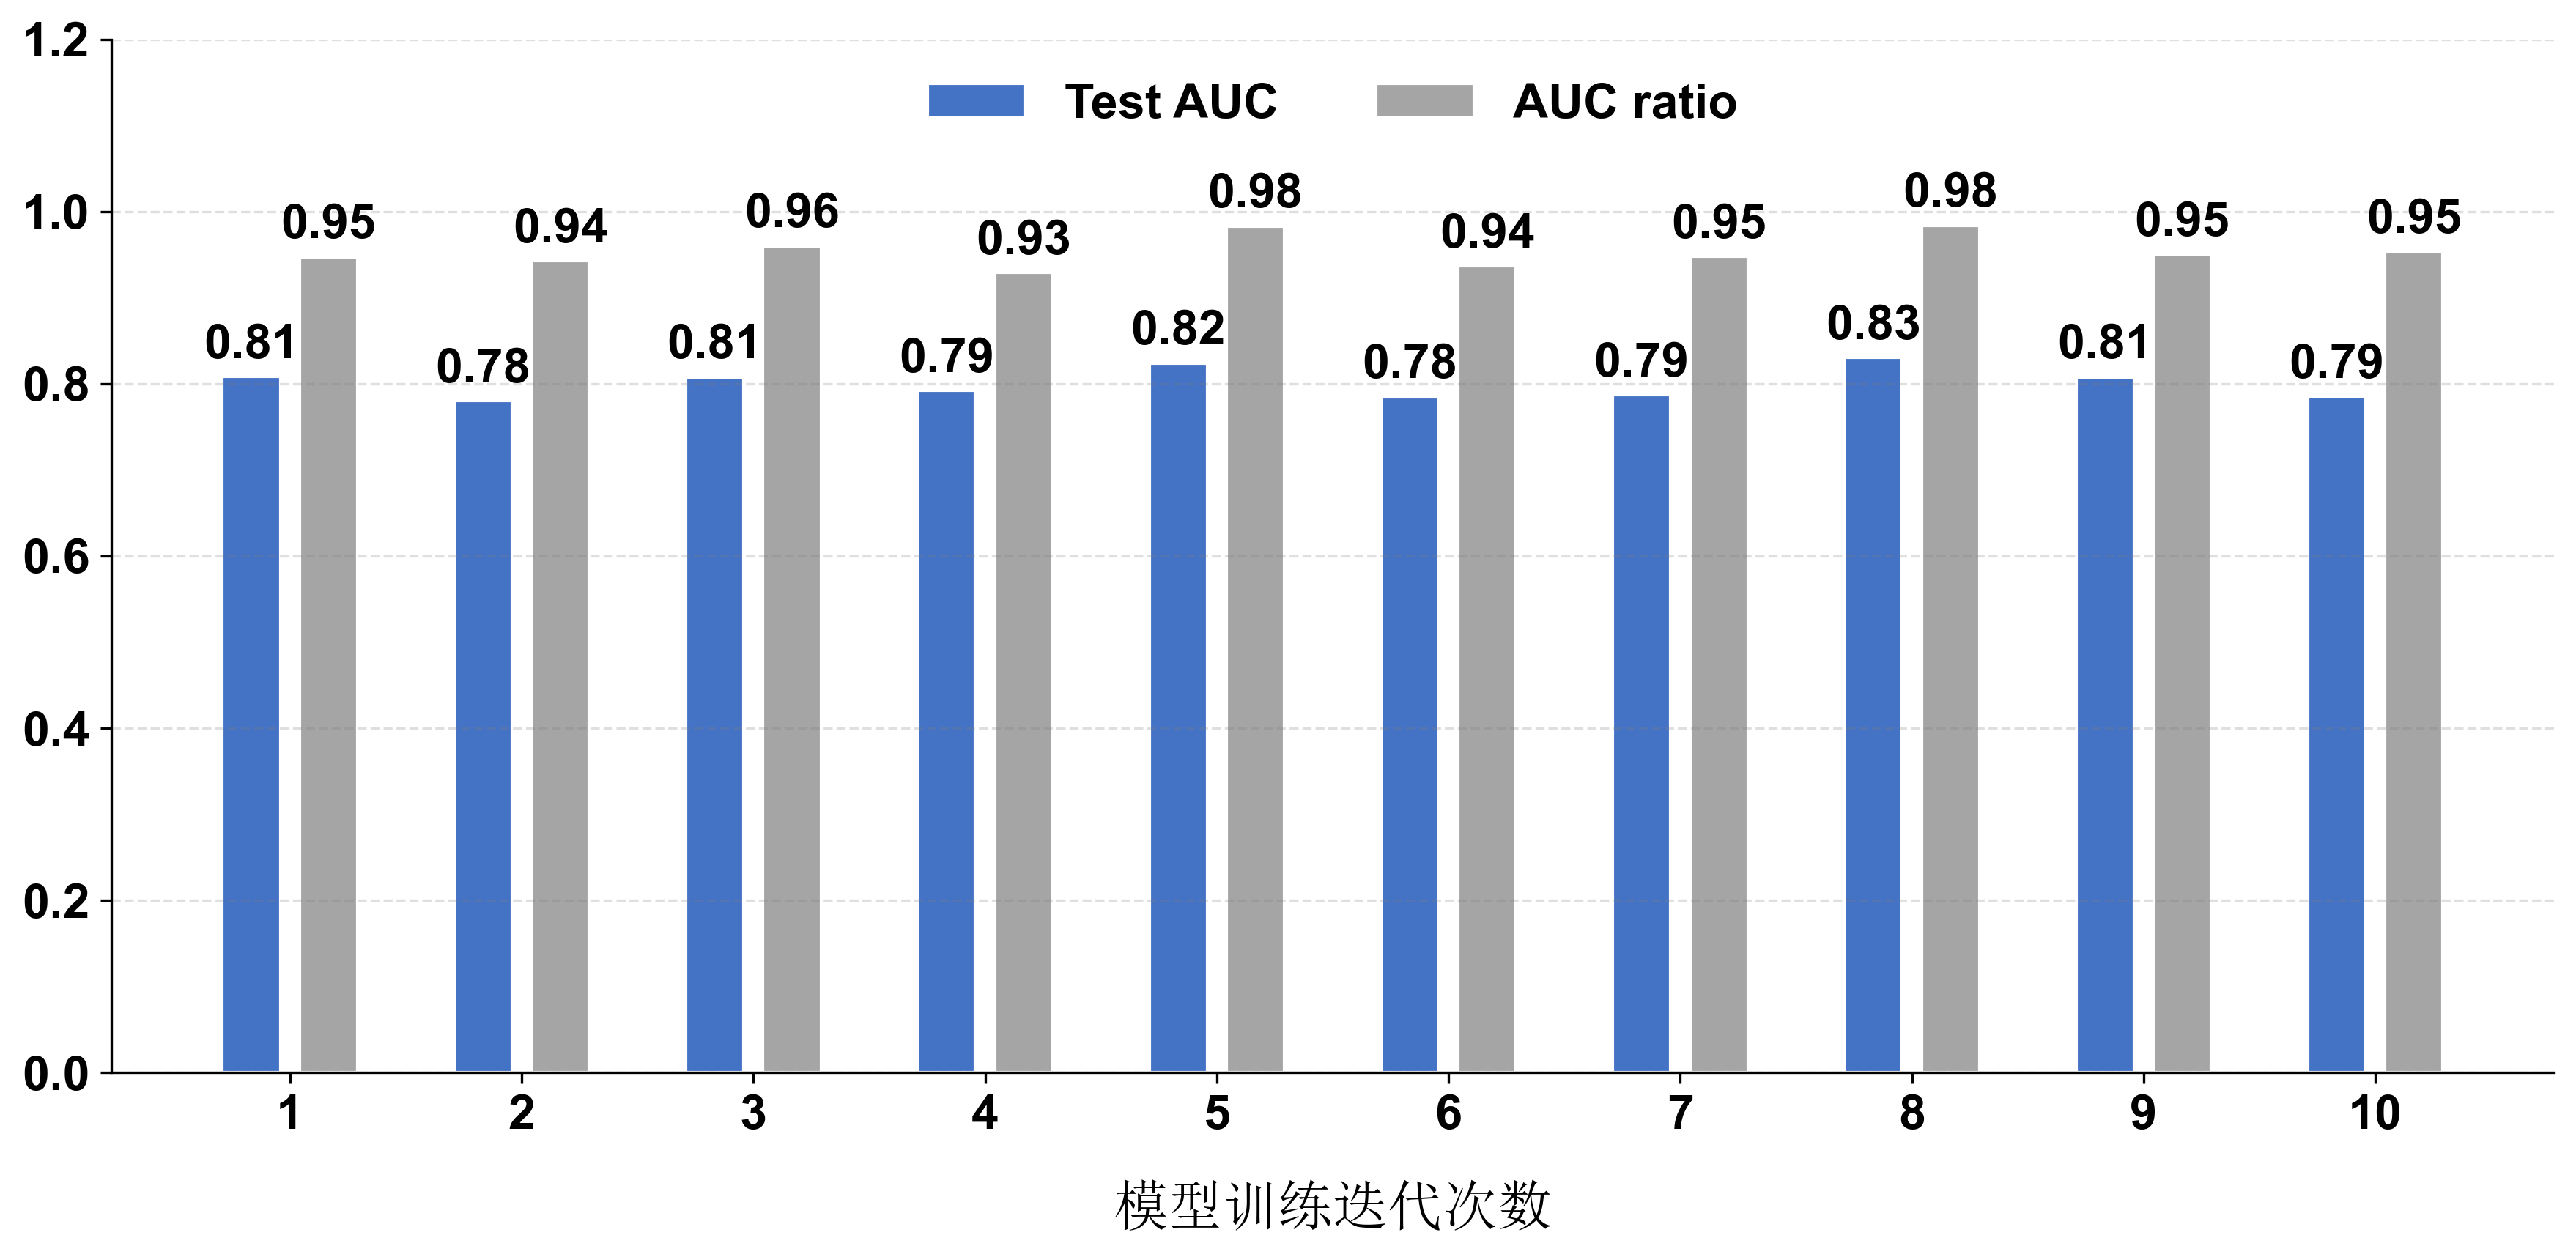

In [23]:
plot_data = df_metrics[['Run', 'Test AUC', 'TSS', 'AUC ratios']]

x = np.arange(len(plot_data['Run']))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

rects1 = ax.bar(x - width / 1.5, plot_data['Test AUC'], width, label='Test AUC', color='#4472C4', edgecolor='white')
# rects2 = ax.bar(x, plot_data['TSS'], width, label='TSS', color='#A9D18E', edgecolor='white')
rects3 = ax.bar(x + width / 1.5, plot_data['AUC ratios'], width, label='AUC ratio', color='#A5A5A5', edgecolor='white')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
# autolabel(rects2)
autolabel(rects3)

# 设置轴标签和标题
ax.set_xlabel('模型训练迭代次数', fontweight='bold', labelpad=15, fontsize=18)
# ax.set_ylabel('Values', fontsize=14, fontweight='bold')
# ax.set_title('Model Performance Metrics across 10 Runs', fontsize=16) # 论文中标题通常在图下方，这里可以不写

# 设置 X 轴刻度
ax.set_xticks(x)
ax.set_xticklabels(plot_data['Run'])

# 设置 Y 轴范围 (通常 MaxEnt 指标在 0-1.1 之间)
ax.set_ylim(0, 1.2)

# 图例 (放在顶部中间)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)

# 去除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加淡色网格线 (仅Y轴)
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.25)

plt.tight_layout()
plt.show()


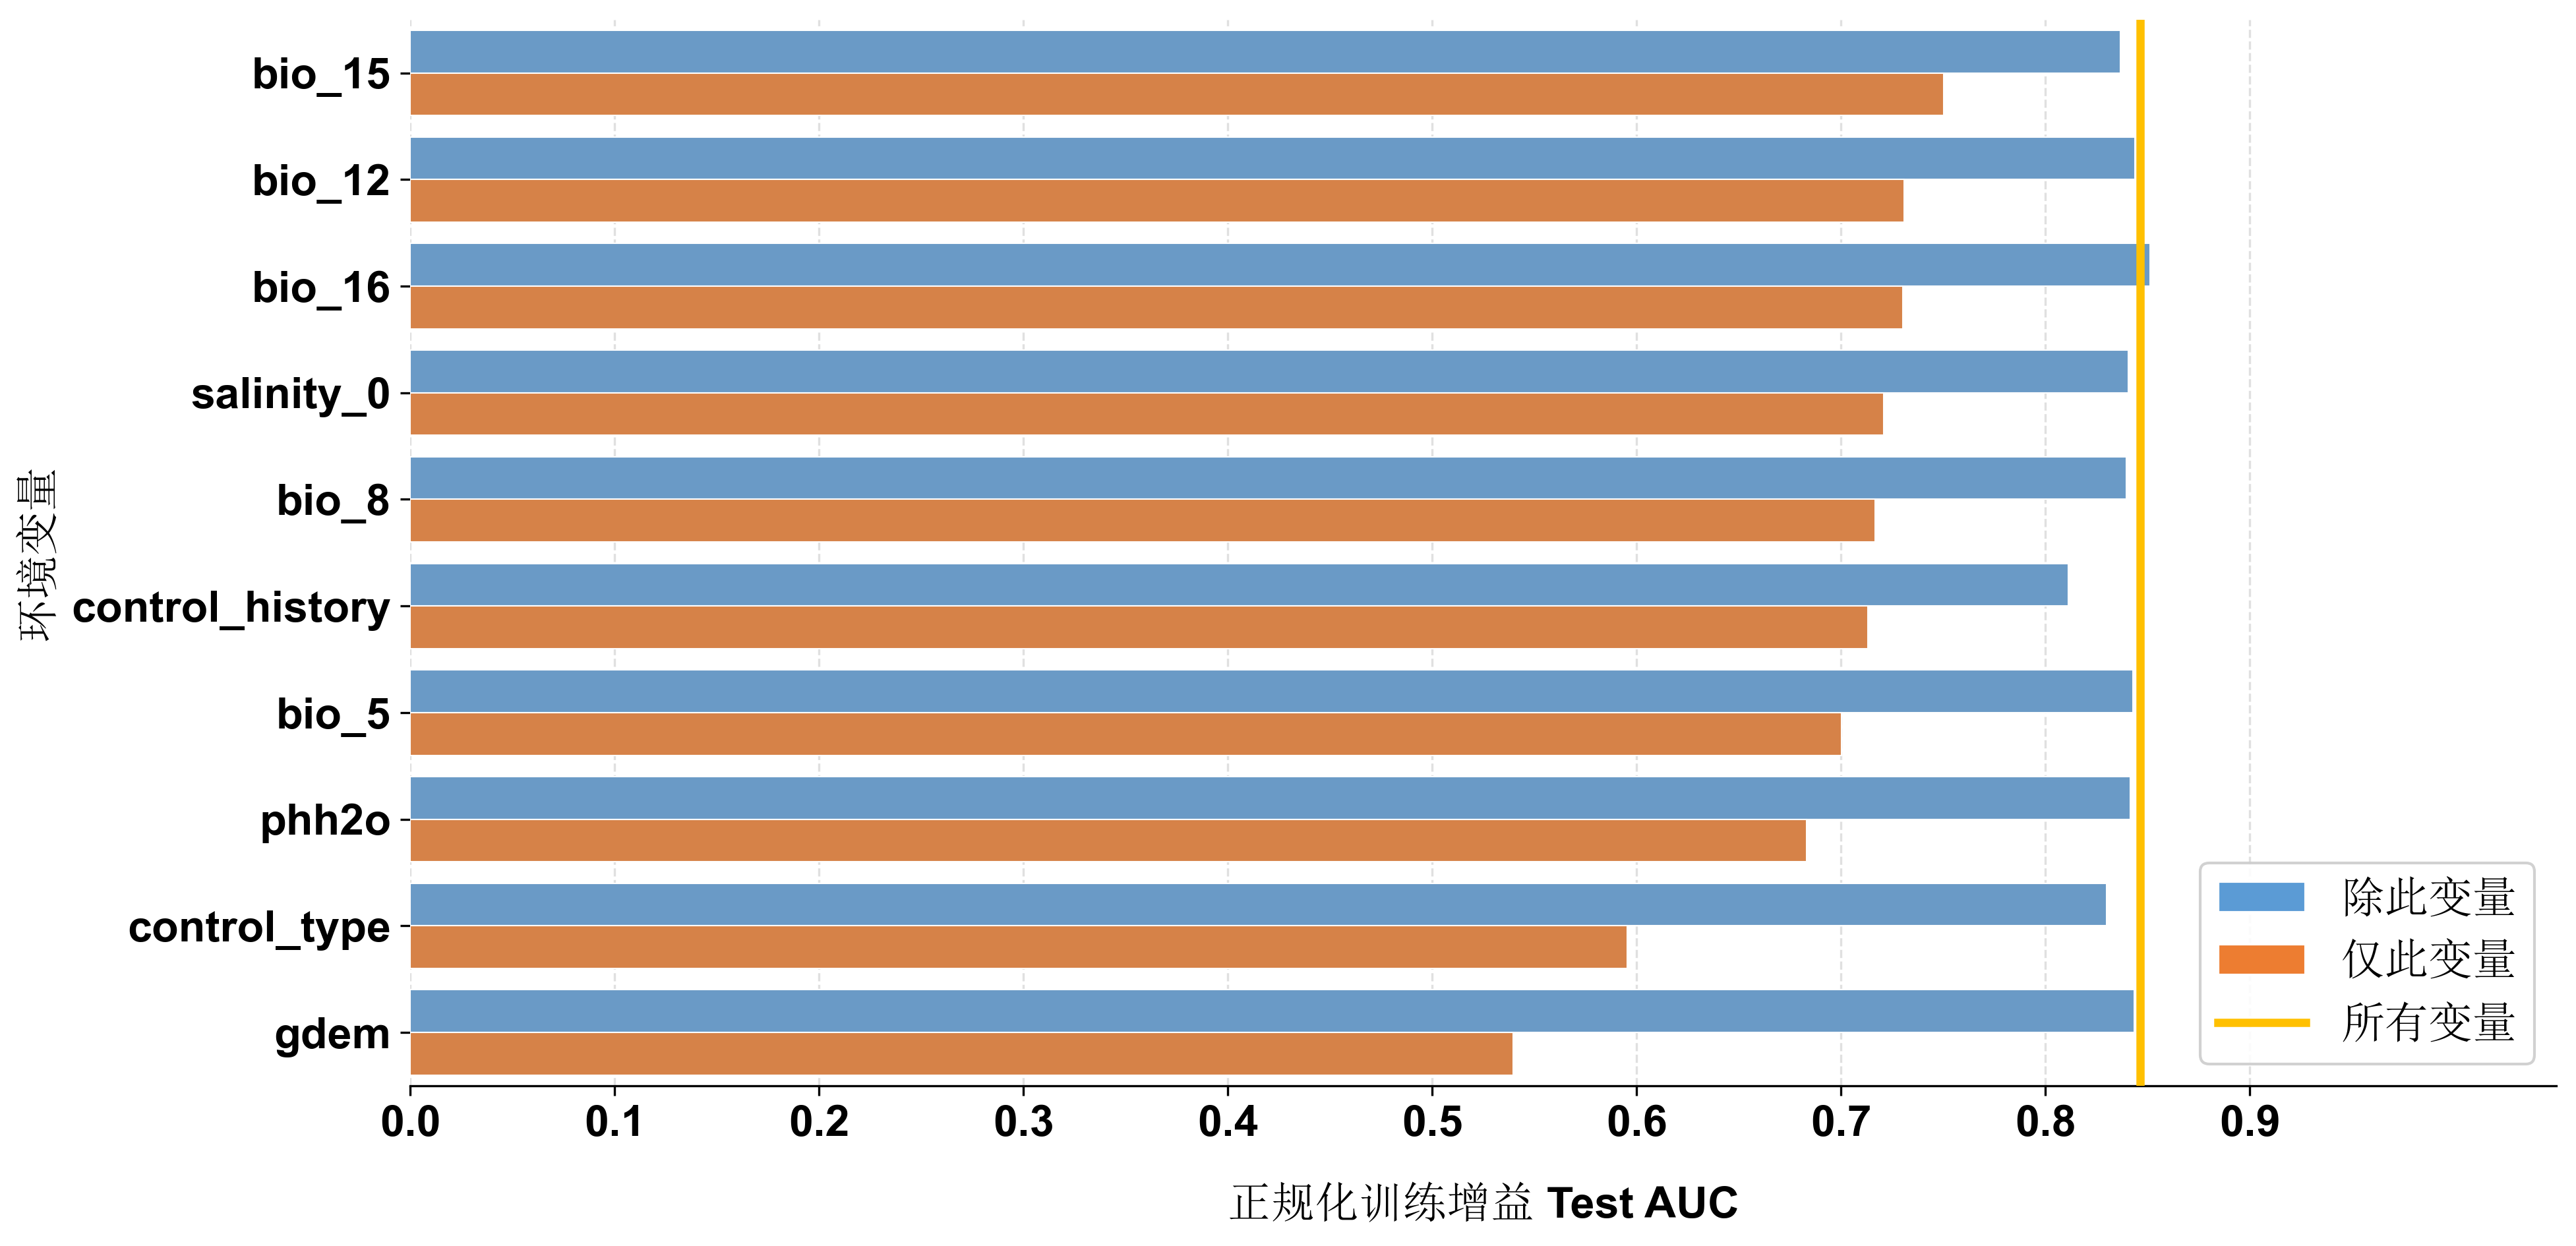

In [24]:
import seaborn as sns
# 读取数据
df_jkn = pd.read_csv('Jackknife_Analysis_Data.csv')

# -------------------------------------------------------
# 2. 数据处理与排序
# -------------------------------------------------------

# 提取基准线 (All Variables)
bf_baseline_row = df_jkn[df_jkn['Variable'] == 'ALL_VARIABLES']
bf_baseline_auc = bf_baseline_row['AUC'].values[0]

# 提取用于绘图的变量 (排除 ALL_VARIABLES)
bf_plot_data = df_jkn[df_jkn['Variable'] != 'ALL_VARIABLES'].copy()

# 为了图表美观，我们按照 "With_Only" (蓝色条/橙色条) 的 AUC 值对变量进行排序
# 这样贡献度最高的变量会排在最上面（或最下面）
bf_sort_order = bf_plot_data[bf_plot_data['Test_Type'] == 'With_Only'] \
                .sort_values('AUC', ascending=False)['Variable'].tolist()

# 设置 Categorical 类型以强制排序
bf_plot_data['Variable'] = pd.Categorical(bf_plot_data['Variable'], categories=bf_sort_order, ordered=True)
bf_plot_data = bf_plot_data.sort_values('Variable')

# -------------------------------------------------------
# 3. 绘图 (复刻参考图风格)
# -------------------------------------------------------

# 设置字体和风格
# plt.rcParams['font.size'] = 14

bf_fig, bf_ax = plt.subplots(figsize=(14, 7), dpi=300)

# 定义配色 (参考图片：橙色和蓝色)
# Without -> 蓝色, With_Only -> 橙色
bf_colors = {'Without': '#5B9BD5', 'With_Only': '#ED7D31'}

# 绘制条形图
sns.barplot(
    data=bf_plot_data,
    y='Variable',
    x='AUC',
    hue='Test_Type',
    hue_order=['Without', 'With_Only'], # 调整顺序，让长条(Without)通常在上面或作为背景
    palette=bf_colors,
    edgecolor='white',
    linewidth=0.5,
    ax=bf_ax
)

# 添加 "With all variables" 的基准线 (黄色/金色)
# 相比于在顶部画一个单独的条，垂直线更能直观对比每个变量缺失后的下降程度
bf_line = bf_ax.axvline(x=bf_baseline_auc, color='#FFC000', linewidth=3, linestyle='-', zorder=5)

# -------------------------------------------------------
# 4. 图表美化
# -------------------------------------------------------

# 设置标题和标签
bf_ax.set_xlabel('正规化训练增益 Test AUC', fontsize=16, fontweight='bold', labelpad=15)
bf_ax.set_ylabel('环境变量', fontsize=16, fontweight='bold')

# 设置图例
# 手动创建一个图例，包含红线
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

bf_legend_elements = [
    Patch(facecolor='#5B9BD5', edgecolor='white', label='除此变量'),
    Patch(facecolor='#ED7D31', edgecolor='white', label='仅此变量'),
    Line2D([0], [0], color='#FFC000', lw=3, label='所有变量')
]

bf_ax.legend(handles=bf_legend_elements, loc='lower right', frameon=True, framealpha=0.9)

# 设置坐标轴范围 (AUC一般在0.5-1.0之间，稍微缩放一下让差异更明显)
# 如果 With Only 很低，可以设为 0
bf_ax.set_xlim(0, 1.05) 

# 去除多余边框
bf_ax.spines['top'].set_visible(False)
bf_ax.spines['right'].set_visible(False)
bf_ax.spines['left'].set_visible(False) # 移除左轴线，只留文字

# 添加网格线 (仅X轴)
bf_ax.xaxis.grid(True, linestyle='--', which='major', color='lightgrey', alpha=0.7)
bf_ax.set_axisbelow(True) # 让网格线在图层下方

x_ticks = np.arange(0, 1, 0.1)
plt.xticks(x_ticks)

# plt.tight_layout()
plt.show()

In [25]:
import jenkspy
probs = pd.read_csv('samples_for_break.csv')['probability'].dropna().values
n_classes = 4
breaks = jenkspy.jenks_breaks(probs, n_classes=n_classes)
for _break in breaks:
    print(f"{_break:.4f}")

0.0000
0.1490
0.3310
0.6621
0.9984


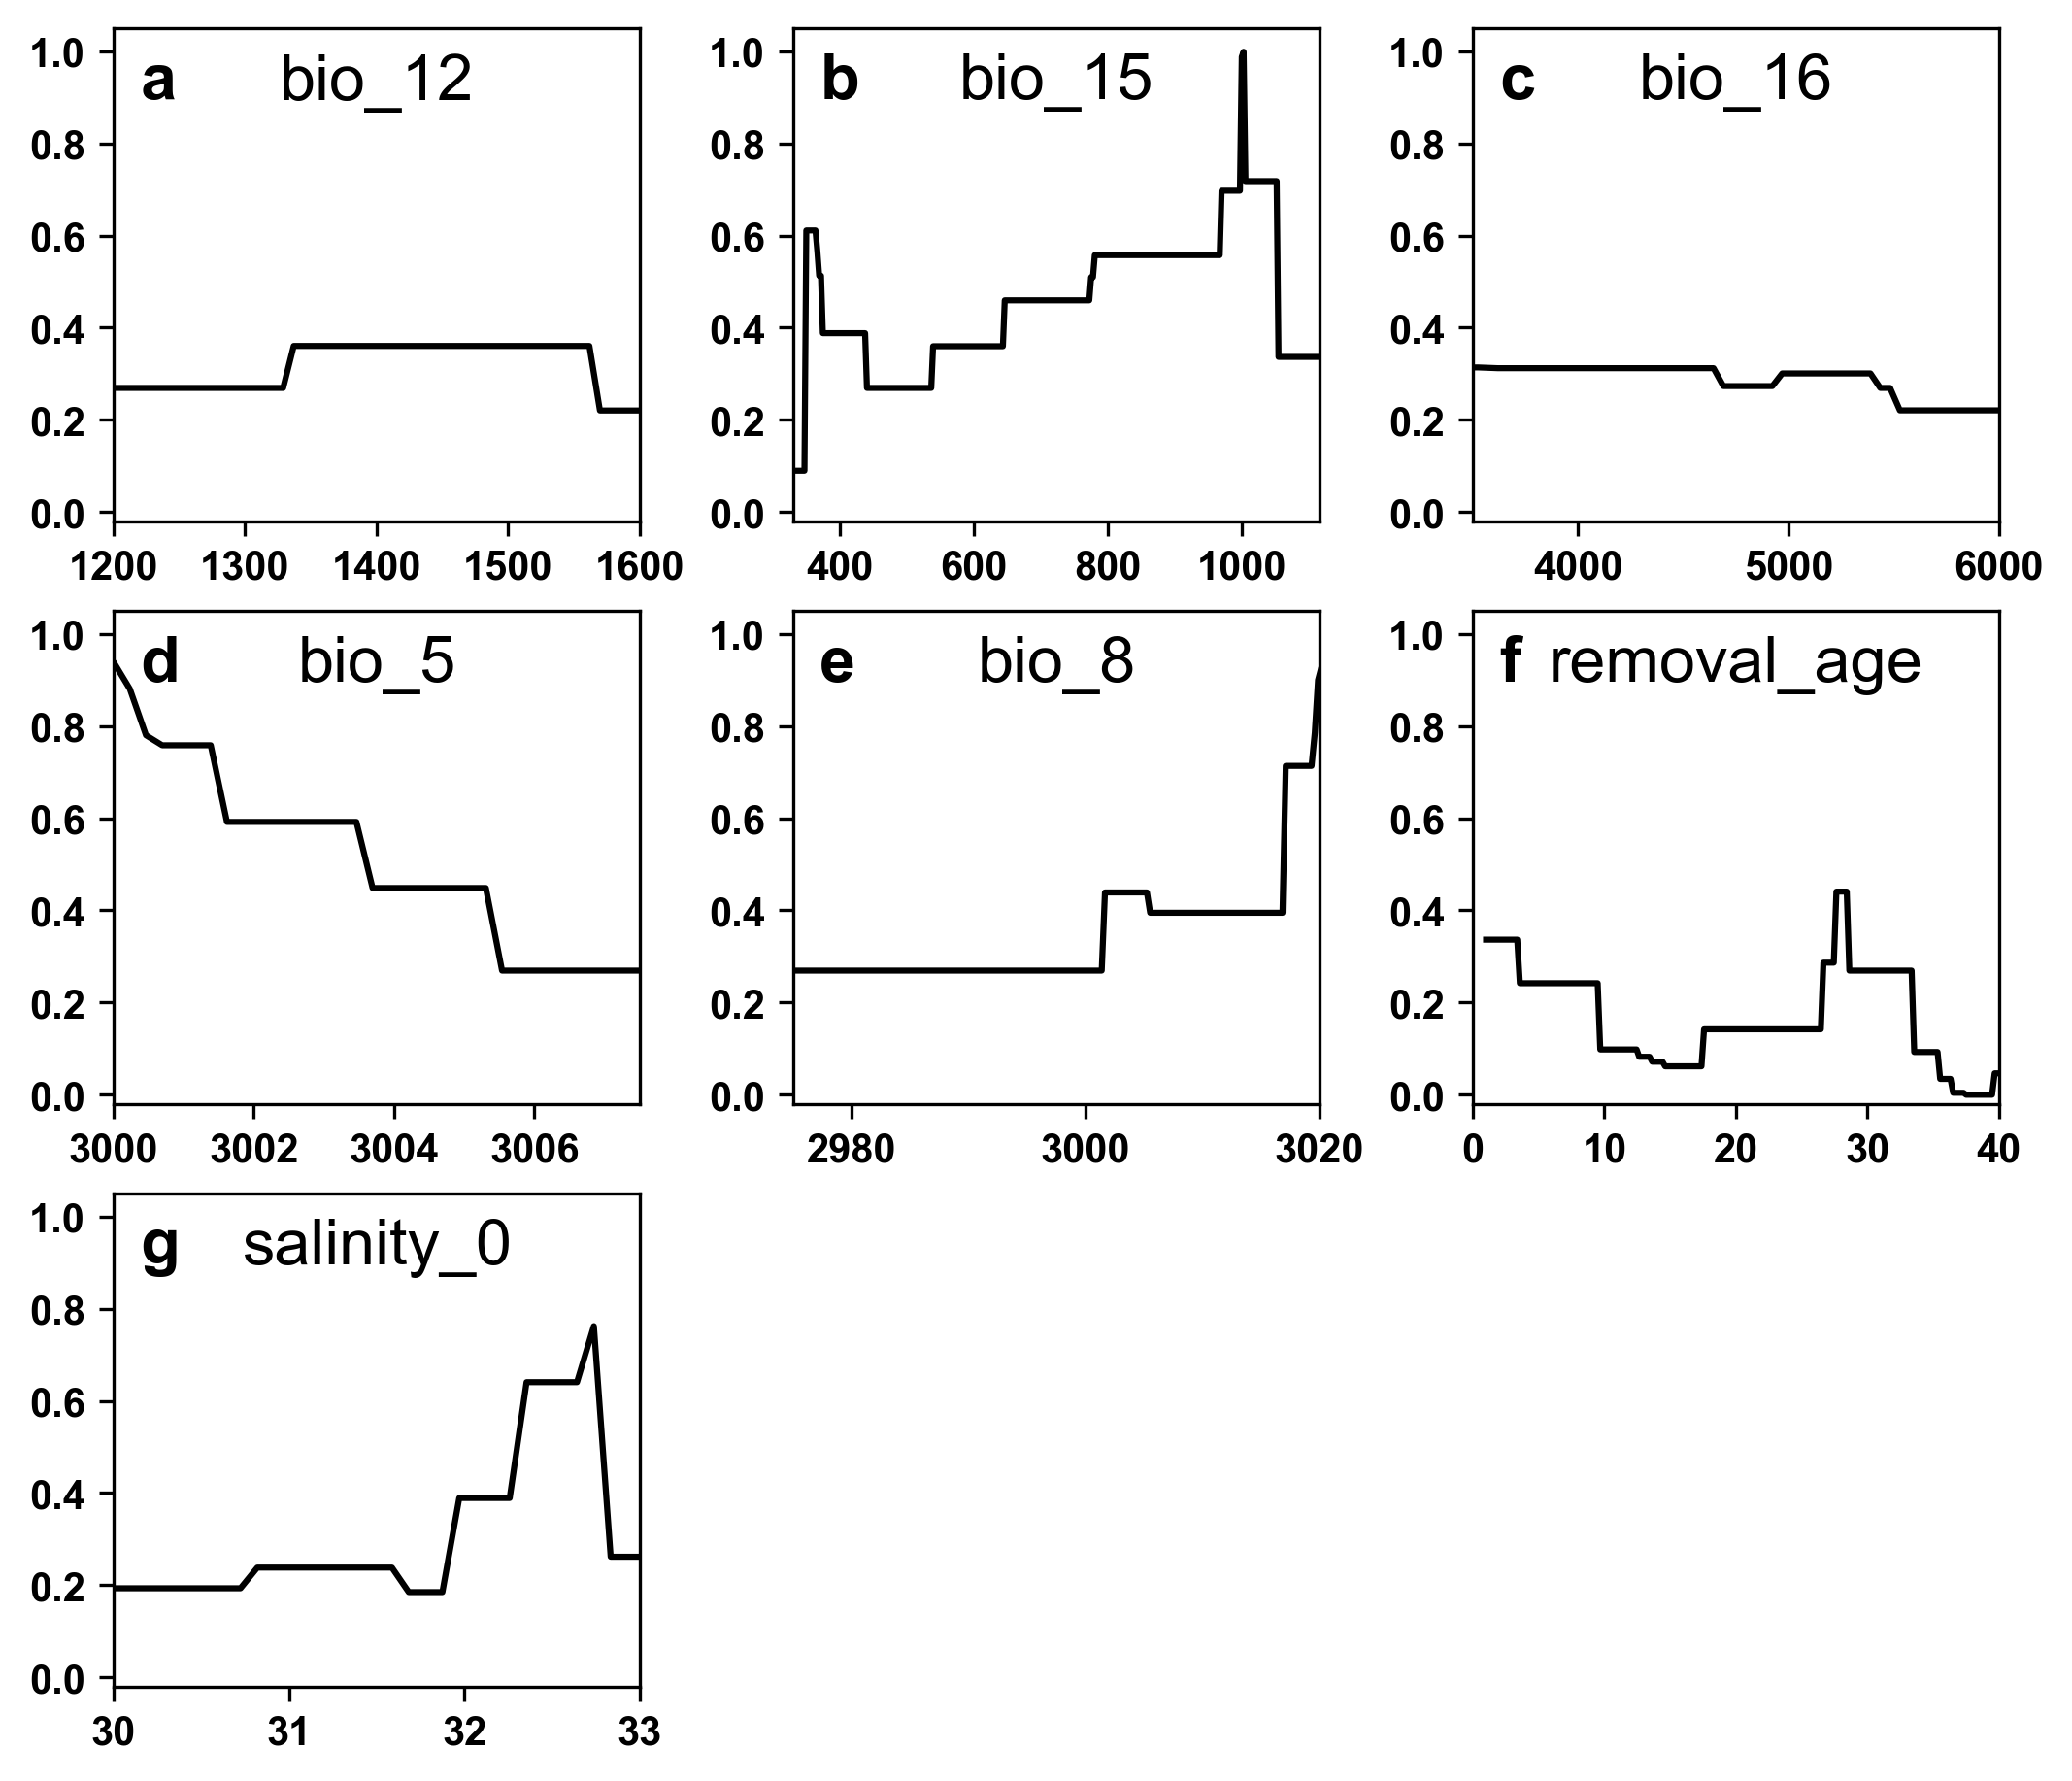

In [26]:
from scipy.signal import savgol_filter

df_curve = pd.read_csv('maxent_response_curves_data.csv')
df_curve = df_curve[~df_curve['variable'].isin(['control_type', 'phh2o', 'gdem'])]
variables = df_curve['variable'].unique()
n_vars = len(variables)
x_limits = {
    'bio_12': (1200, 1600),
    'bio_15': (330, 1115),
    'bio_16': (3500, 6000),
    'bio_8': (2975, 3020),
    'bio_5': (3000, 3007.5),
    'removal_age': (0, 40),
    'salinity_0': (30, 33),
}

n_cols = 3 
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 2 * n_rows), constrained_layout=True, dpi=300)

if n_vars > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, var_name in enumerate(variables):

    ax = axes[i]
    subset = df_curve[df_curve['variable'] == var_name].sort_values('x_value')
    if var_name in x_limits:
        ax.set_xlim(x_limits[var_name])
        
    x = subset['x_value']
    y = subset['probability']
    
    ax.plot(x, y, color='black', linewidth=1.5) 
    
    ax.set_ylim(-0.02, 1.05)
    ax.text(0.5, 0.95, var_name, transform=ax.transAxes, 
            ha='center', va='top', fontweight='normal')
    
    label_char = chr(97 + i) 
    ax.text(0.05, 0.95, label_char, transform=ax.transAxes, 
            ha='left', va='top', fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=10)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

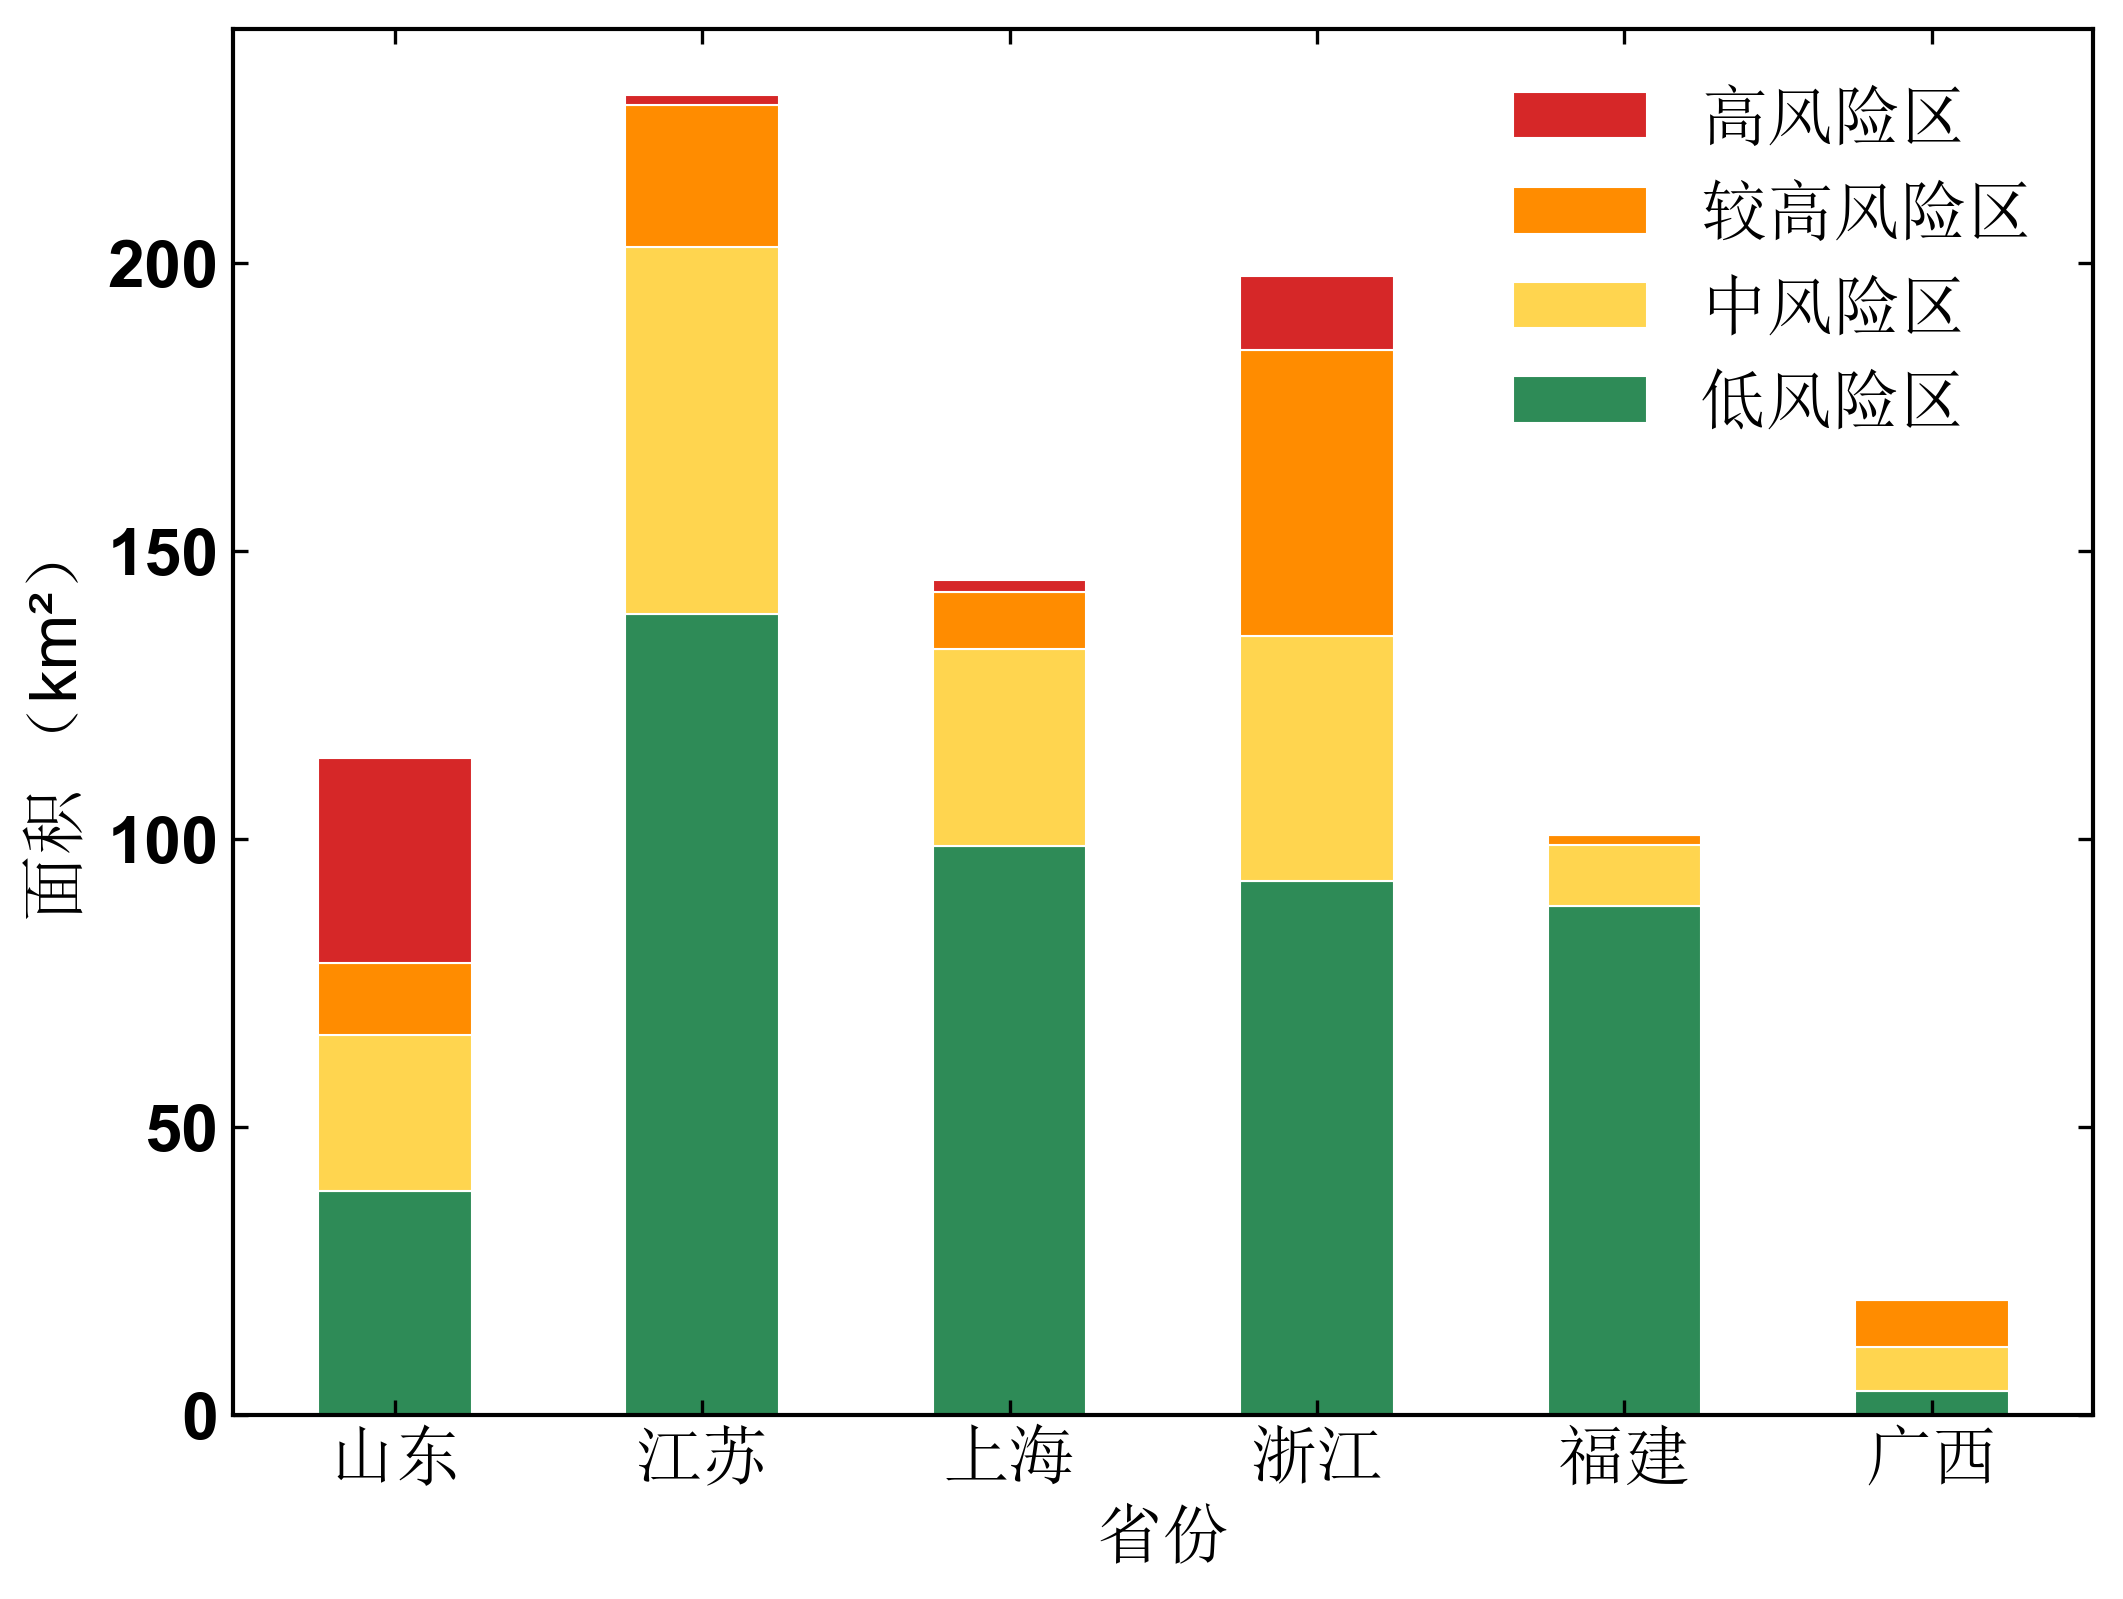

In [27]:
df_area = pd.read_csv('province_risk_area_stats.csv')
df_area['total_area'] = df_area[['area_level_1_km2', 'area_level_2_km2', 'area_level_3_km2', 'area_level_4_km2']].sum(axis=1)
name_map = {
    'SD': '山东',
    'JS': '江苏',
    'SH': '上海',
    'ZJ': '浙江',
    'FJ': '福建',
    'GDGX': '广西',
}
df_area['province_cn'] = df_area['province'].map(name_map)
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

colors = ['#2E8B57', '#FFD54F', '#FF8C00', '#D62728']
labels = ['低风险区', '中风险区', '较高风险区', '高风险区']

x = df_area['province_cn']
y1 = df_area['area_level_1_km2']
y2 = df_area['area_level_2_km2']
y3 = df_area['area_level_3_km2']
y4 = df_area['area_level_4_km2']

bar_width = 0.5

p1 = ax.bar(x, y1, width=bar_width, label=labels[0], color=colors[0], edgecolor='white', linewidth=0.5)
p2 = ax.bar(x, y2, width=bar_width, bottom=y1, label=labels[1], color=colors[1], edgecolor='white', linewidth=0.5)
p3 = ax.bar(x, y3, width=bar_width, bottom=y1+y2, label=labels[2], color=colors[2], edgecolor='white', linewidth=0.5)
p4 = ax.bar(x, y4, width=bar_width, bottom=y1+y2+y3, label=labels[3], color=colors[3], edgecolor='white', linewidth=0.5)

# for i in range(len(x)):
#     total = df_area['total_area'].iloc[i]
#     ax.text(i, total + total * 0.01,
#             f'{total:,.1f}',
#             ha='center', va='bottom', 
#             fontweight='bold', color='black')

handles, legend_labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], legend_labels[::-1], 
          loc='upper right', frameon=False)

ax.set_ylabel('面积 （km²）')
# bf_ax.set_ylabel('环境变量', fontsize=16, fontweight='bold')
ax.set_xlabel('省份')

ax.tick_params(axis='x')
ax.tick_params(axis='y')

# ax.set_ylim(0, df_area['total_area'].max() * 1.1)
ax.tick_params(direction='in', top=True, right=True) 

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.show()

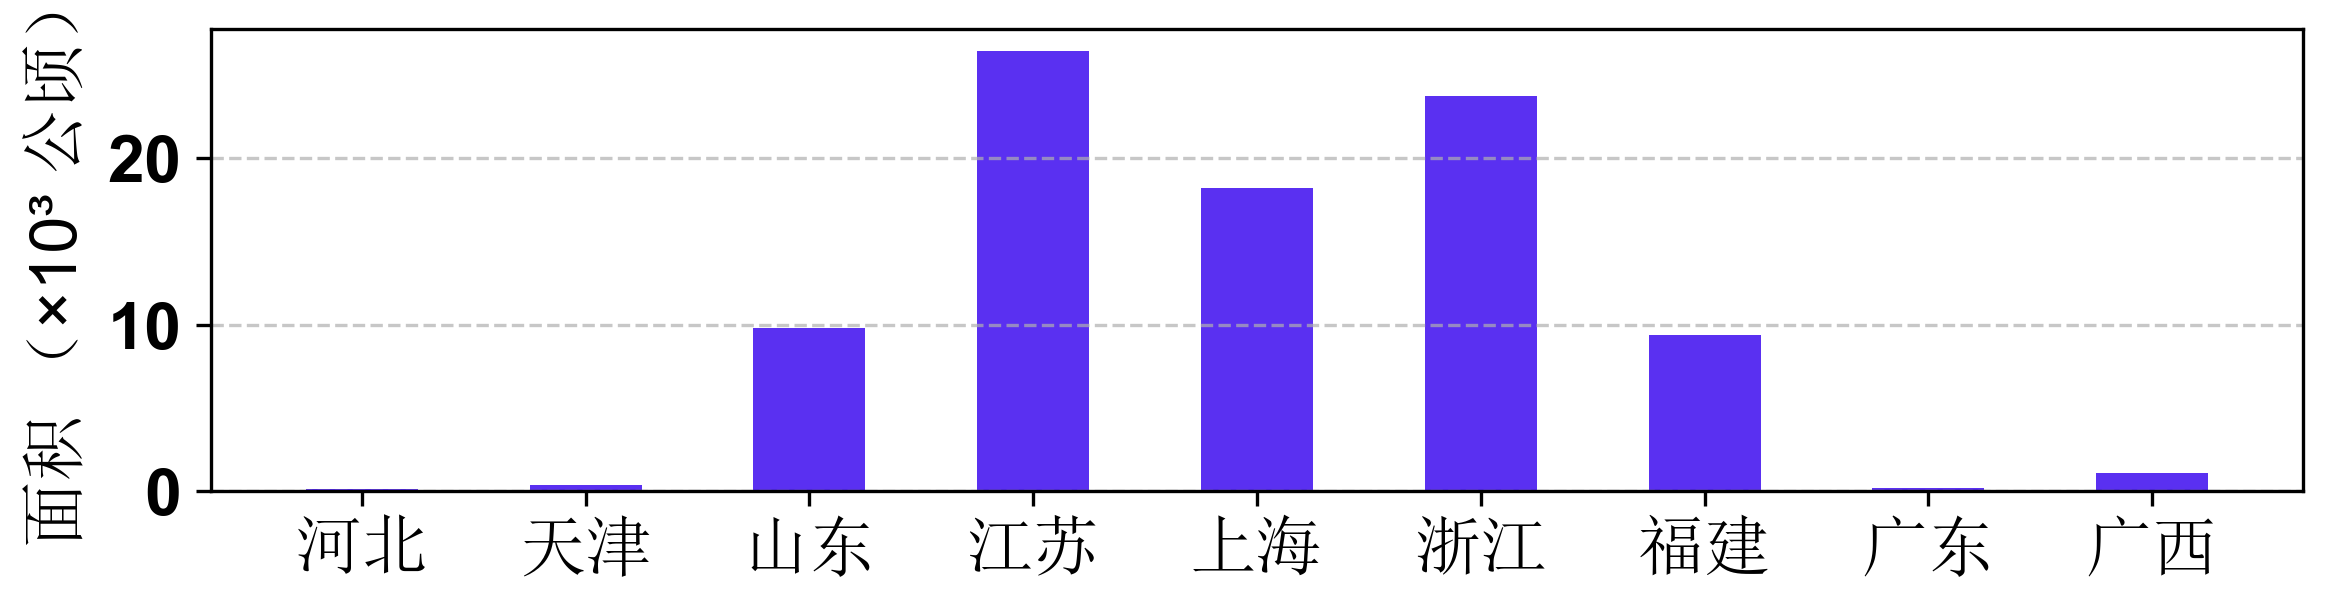

In [28]:
import matplotlib.pyplot as plt

# 1. 准备数据（9组）
labels = ['河北','天津','山东','江苏','上海','浙江','福建','广东','广西']
values = [147, 354, 9795, 26380, 18193, 23710, 9375, 210, 1087]

# 2. 创建图形
plt.figure(figsize=(9, 2), dpi=300)

# 3. 绘制柱状图
plt.bar(labels, [value/1000 for value in values], width=0.5, color="#5A30F1")

# 4. 添加标题和标签（可选）
# plt.xlabel("Category")
plt.ylabel("面积 （×10³ 公顷）")
plt.grid(True, alpha=0.7, axis='y', linestyle='--')
# 5. 显示图像
plt.show()